### Step 1: Setting Up
This cell imports essential libraries for data manipulation, visualization, machine learning models, and saving models. `sqlite3` is used to read the dataset stored in a SQLite database.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import sqlite3

### Step 2: Fetching data
This step connects to the SQLite database containing the African farm data and executes a SQL query to merge several feature tables into one comprehensive DataFrame.

In [3]:
# Load Data from SQLite Database
db_path = "Maji_Ndogo_farm_survey_small.db"
conn = sqlite3.connect(db_path)

query = """
SELECT * FROM geographic_features
LEFT JOIN weather_features USING (Field_ID)
LEFT JOIN soil_and_crop_features USING (Field_ID)
LEFT JOIN farm_management_features USING (Field_ID)
"""

raw_df = pd.read_sql_query(query, conn)
conn.close()

### Step 3: Data Cleaning
This cell performs cleaning tasks such as renaming columns and correcting inconsistent crop name values. It also drops irrelevant columns like `Weather_station` and any missing values.

In [4]:
# Basic Cleaning and Renaming
raw_df.rename(columns={'Annual_yield': 'Crop_type', 'Crop_type': 'Annual_yield'}, inplace=True)
raw_df.replace({'cassaval': 'cassava', 'wheatn': 'wheat', 'teaa': 'tea'}, inplace=True)
df = raw_df.copy()

# Drop irrelevant columns and handle missing values
df.drop(columns=['Weather_station', 'Field_ID'], inplace=True, errors='ignore')
df.dropna(inplace=True)

### Step 4: Exploration
This cell creates a scatter plot to visualize the relationship between average temperature and crop yield. The second plot is a heatmap showing correlations between all numeric variables.

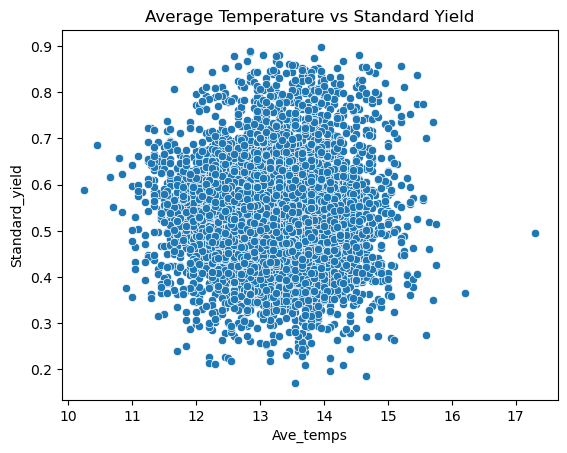

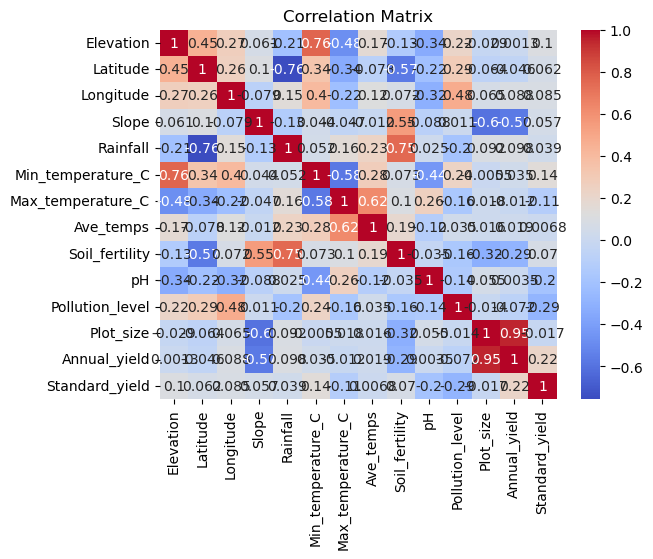

In [5]:
# Visualizations
sns.scatterplot(x='Ave_temps', y='Standard_yield', data=df)
plt.title('Average Temperature vs Standard Yield')
plt.show()

#sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
#plt.title('Correlation Matrix')
#plt.show()



# Correlation Heatmap Only for Numeric Features
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


### Step 5 Feature Engineering
This section performs feature engineering: selecting input (`X`) and output (`y`) variables and converting any categorical variables into numeric format using one-hot encoding.

In [6]:
# Feature Engineering
X = df.drop(['Standard_yield'], axis=1)
y = df['Standard_yield']

# Convert categorical to numeric if any
X = pd.get_dummies(X, drop_first=True)

### Step 6:  Standardization
Here, all the features are standardized (mean=0, std=1) using `StandardScaler`. This is critical before applying gradient descent to ensure features are on the same scale.

In [7]:
# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Step 7: Splitting
The dataset is split into training and testing sets (80% training, 20% testing) to evaluate the model's performance on unseen data.

In [8]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Step 8: Training
This code initializes a linear regression model using stochastic gradient descent. The model is trained over 1000 iterations while storing the loss after each iteration for plotting.

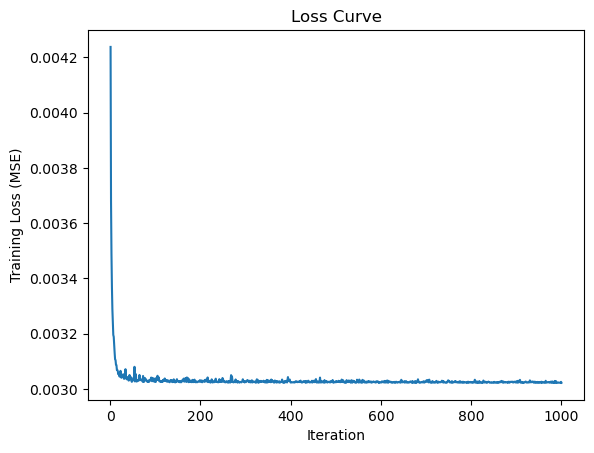

In [9]:
# Train Linear Regression with Gradient Descent
lr_model = SGDRegressor(max_iter=1000, learning_rate='invscaling', eta0=0.01)
losses = []

for i in range(1, 1001):
    lr_model.partial_fit(X_train, y_train)
    y_pred_train = lr_model.predict(X_train)
    loss = mean_squared_error(y_train, y_pred_train)
    losses.append(loss)

plt.plot(range(1, 1001), losses)
plt.xlabel("Iteration")
plt.ylabel("Training Loss (MSE)")
plt.title("Loss Curve")
plt.show()

### Step 9: Comparing Models
This scatter plot compares the actual vs. predicted values of crop yield, helping visualize how well the model is performing.

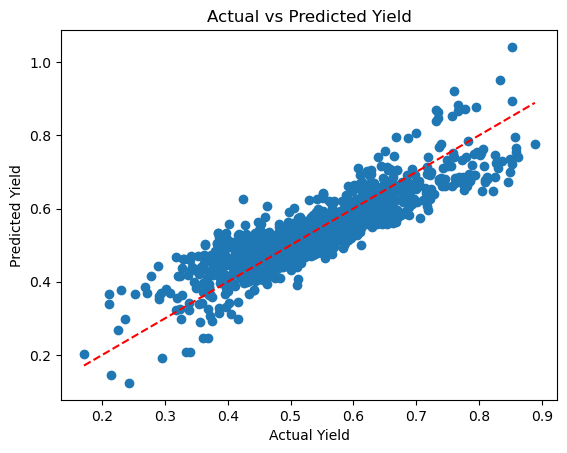

In [10]:
# Plot Predicted vs Actual
y_pred_test = lr_model.predict(X_test)
plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [11]:
# Compare Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

best_model = None
best_score = float("inf")

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    print(f"{name} MSE: {mse:.4f} | R2 Score: {r2_score(y_test, preds):.4f}")
    if mse < best_score:
        best_score = mse
        best_model = model

Linear Regression MSE: 0.0033 | R2 Score: 0.7519
Decision Tree MSE: 0.0012 | R2 Score: 0.9095
Random Forest MSE: 0.0005 | R2 Score: 0.9615


### Step 10: Best Model
The model with the best performance (lowest MSE) is saved to a file named `best_model.pkl` for later use.

In [12]:
# Save Best Model
joblib.dump(best_model, "best_model.pkl")
print("Best model saved as best_model.pkl")

Best model saved as best_model.pkl


### Step 11 Explanation
This is a prediction script stub. You can load the saved model and make predictions on new data after applying the same preprocessing steps.

In [ ]:
# Prediction Script Example (Use separately)
# new_data = pd.DataFrame({
#     'Ave_temps': [25],
#     'Rainfall': [120],
#     ... # include all other required columns
# })
# new_data_scaled = scaler.transform(new_data)
# prediction = best_model.predict(new_data_scaled)
# print("Predicted yield:", prediction)